In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import os
from IPython import display

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-03 14:38:07,514	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-02-03 14:38:07.721024: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-03 14:38:07.721049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-03 14:38:07.721979: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to re

## Load Data (excluding behavioural neurons)

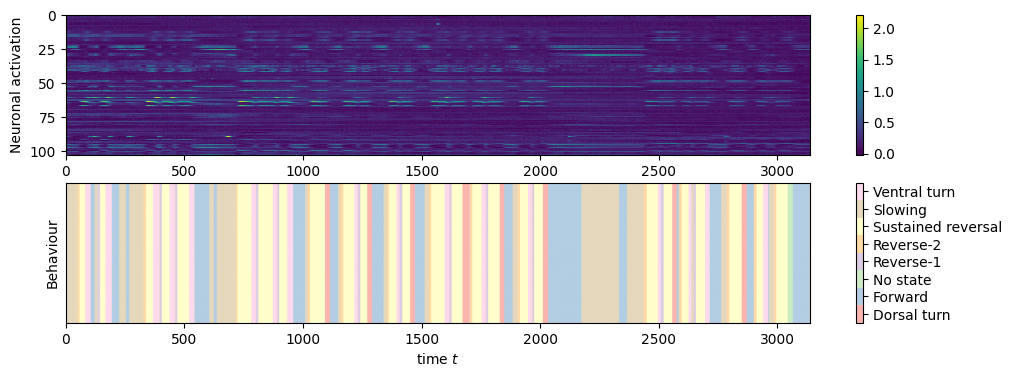

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [2]:
worm_num = 0
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = '../datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour


# Visualise Neuronal and Behavioural data

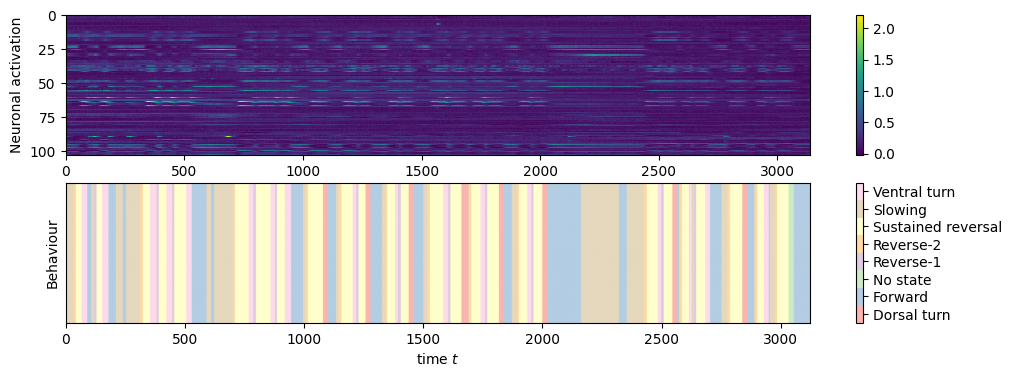

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [33]:
plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

## Latent time series visualisation

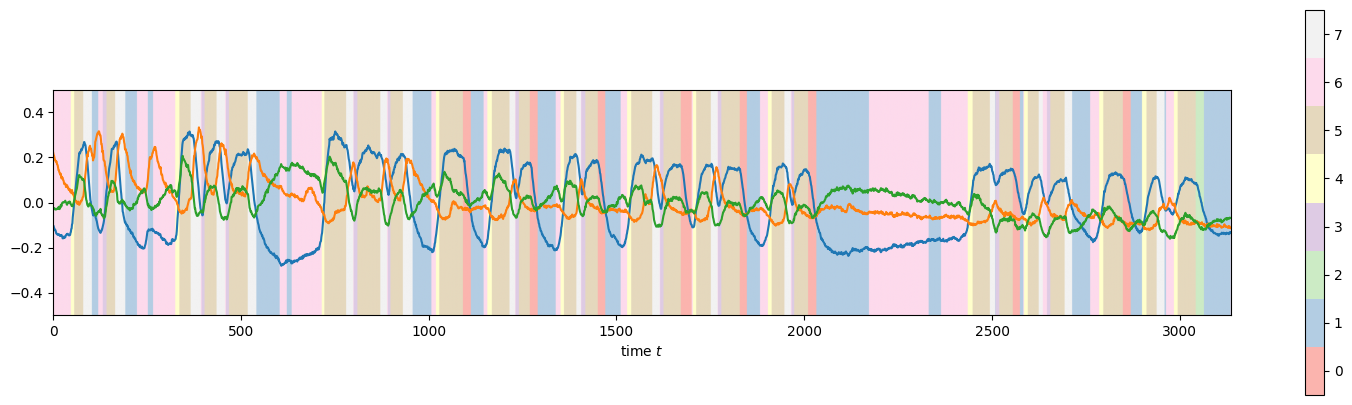

In [3]:
# To use the comparison plot we first need an embedding
pca = PCA(n_components=3)
y_pca = pca.fit_transform(x)
vis = LatentSpaceVisualiser(y_pca, b, b_names=data.behaviour_names, legend=True)
vis.plot_latent_timeseries()

# Comparision Model

## Movie Maker (GIF)

In [34]:
# Load Bundle-Net trajectory for visualisation
y = np.loadtxt('../datasets/generated/saved_embeddings/Y0__BunDLeNet_worm_0')
b = np.loadtxt('../datasets/generated/saved_embeddings/B__BunDLeNet_worm_0')

True

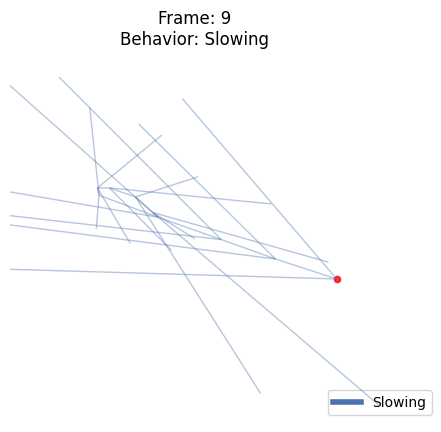

In [35]:
# This can take quite some time to render with bigger datasets
# That is why we cut our dataset for display purposes:
vis = LatentSpaceVisualiser(
    y[:10], 
    b[:10], 
    b_names=data.behaviour_names, 
    legend=True)
vis.make_movie(
    fps=30, 
    filename='../figures/worm_0_movie.gif',
    show_fig=False)

True

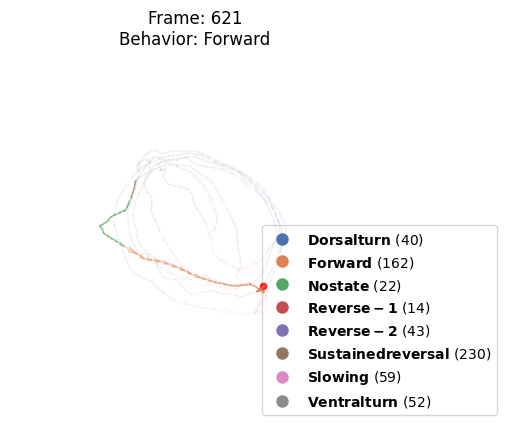

In [10]:
# The make_movie method has parameters that allow the user to fade the animation or add a background manifold.
vis.make_movie(
    fps=50, 
    filename='../figures/worm_0_fading_movie.gif',
    show_fig=False,
    initial_alpha=0.05,
    fade=100)
os.chdir('figures')

<img src="figures/worm_0_fading_movie.gif">
